<a href="https://colab.research.google.com/github/Ziqi-Li/GEO4162C/blob/fall-24/notebooks/Bivariate_color_maps_in_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bivariate mapping

ivariate mapping is a type of data visualization technique that simultaneously displays two variables on a single map by using color combinations. Each variable is represented along an axis with levels (e.g., low, medium, high), and colors are combined to show areas where values of the two variables overlap.

How Bivariate Mapping Works
- Variable Selection: Two variables are selected, often related, such as income level and educational attainment.
- Color Encoding: Each variable is assigned a range of colors across its values. For example, income might range from light yellow to dark red, while education might range from light blue to dark blue.
- Color Blending: The colors are combined in each map area to represent the intersection of the two variables' values, creating unique shades that represent different combinations.


For example, on a bivariate map where income is represented by shades of yellow-red and education by shades of blue, a dark red-blue might indicate high income and high education, while a light yellow-blue could show low income and high education.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load example florida geospatial data

path = "https://raw.githubusercontent.com/Ziqi-Li/GEO4162C/1c69903dc7d59e49b31bd1b56b7e84399c9cd5dc/data/fl_pop.geojson"

fl = gpd.read_file(path)


In [2]:
fl.columns

Index(['STATEFP10', 'COUNTYFP10', 'COUNTYNS10', 'GEOID10', 'NAME10',
       'NAMELSAD10', 'LSAD10', 'CLASSFP10', 'MTFCC10', 'CSAFP10', 'CBSAFP10',
       'METDIVFP10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'NAME', 'total_population', 'monthly_housing_costs',
       'population_drive_to_work', 'state', 'county', 'geometry'],
      dtype='object')

Here I write a helper function.

In [3]:
from matplotlib.colors import ListedColormap
from matplotlib.colors import to_rgb


def make_bi_variate_map(gdf,x_var,y_var, x_colors, y_colors,legend_pos=[0.1, 0.1, 0.35, 0.35]):

  # Sample data: create two variables with different ranges for demonstration
  gdf['var1'] = fl[x_var]
  gdf['var2'] = fl[y_var]

  # Define categories for bivariate mapping
  gdf['var1_cat'] = pd.qcut(fl['var1'], q=3, labels=[1, 2, 3])  # Three categories for var1
  gdf['var2_cat'] = pd.qcut(fl['var2'], q=3, labels=[1, 2, 3])  # Three categories for var2

  # Combine categories for color encoding
  fl['bivariate_cat'] = fl['var1_cat'].astype(str) + fl['var2_cat'].astype(str)


  # Convert hex colors to RGB
  x_colors_rgb = [to_rgb(color) for color in x_colors]
  y_colors_rgb = [to_rgb(color) for color in y_colors]

  # Re-create the bivariate color legend grid with the updated colors
  fig, ax = plt.subplots(figsize=(8, 8))

  ax.set_axis_off()

  ax_legend = ax.inset_axes(legend_pos)
  ax_legend.set_axis_off()

  levels = ['Low', 'Medium', 'High']

  size = len(levels)

  blended_colors = []

  for i in range(size):
      for j in range(size):
        # Interpolate colors based on position in the grid
          x_blend = (1 - i / (size - 1)) * np.array(x_colors_rgb[0]) + (i / (size - 1)) * np.array(x_colors_rgb[-1])
          y_blend = (1 - j / (size - 1)) * np.array(y_colors_rgb[0]) + (j / (size - 1)) * np.array(y_colors_rgb[-1])

        # Average the x and y blended colors to get the final blended color
          blended_color = (x_blend + y_blend) / 2

        # Draw each square with the blended color
          ax_legend.add_patch(plt.Rectangle((j, size - i - 1), 1, 1, color=blended_color, ec='black', linewidth=0.5))

          blended_colors.append(blended_color)

  cmap = ListedColormap(blended_colors)

  gdf.plot(ax=ax,column="bivariate_cat",cmap=cmap, ec='black', linewidth=0.5)

  # Add labels to each axis
  for i, level in enumerate(levels):
      ax_legend.text(-0.25, size - i - 0.5, level, ha='right', va='center', fontsize=9)
      ax_legend.text(i + 0.5, size + 0.25, level, ha='center', va='bottom', fontsize=9)

  # Labels for each axis
  ax_legend.text(-1.5, size / 2, x_var, ha='center', va='center', rotation='vertical', fontsize=10)
  ax_legend.text(size / 2, size + 1, y_var, ha='center', va='center', fontsize=10)

  ax_legend.set_xlim(-1.5, size)
  ax_legend.set_ylim(-1, size + 1)



In [4]:
fl.columns

Index(['STATEFP10', 'COUNTYFP10', 'COUNTYNS10', 'GEOID10', 'NAME10',
       'NAMELSAD10', 'LSAD10', 'CLASSFP10', 'MTFCC10', 'CSAFP10', 'CBSAFP10',
       'METDIVFP10', 'FUNCSTAT10', 'ALAND10', 'AWATER10', 'INTPTLAT10',
       'INTPTLON10', 'NAME', 'total_population', 'monthly_housing_costs',
       'population_drive_to_work', 'state', 'county', 'geometry'],
      dtype='object')

To call teh function, you would need to identify the two columns of interest and what color to use. You can ask GPT for help regarding color choices.

In [5]:
x_var = "total_population"
y_var = "monthly_housing_costs"

#Ask ChatGPT for color ideas:
#Prompt: Can you give me some color suggestion to for bivariate mapping
x_colors = ["#ffcccc", "#ff6666", "#b30000"] # reds
y_colors = ["#cce5ff", "#6699ff", "#003399"] # blues


Actual code to call the above helper function.

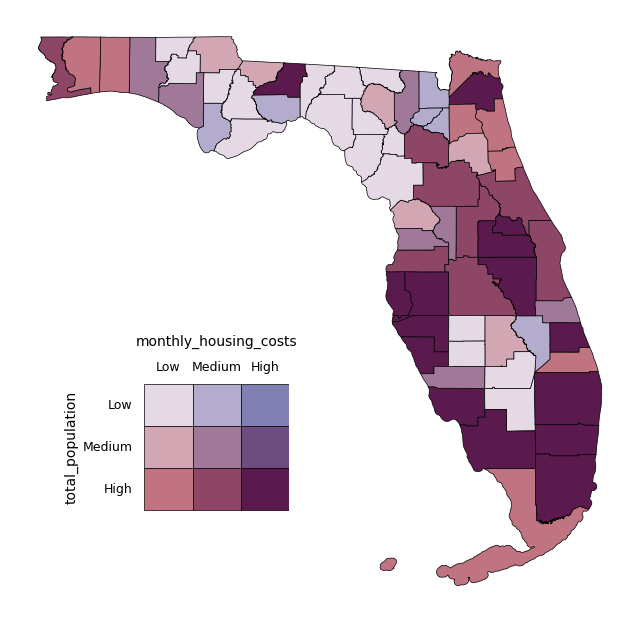

In [8]:
make_bi_variate_map(fl,x_var,y_var, x_colors, y_colors,legend_pos=[0.1, 0.1, 0.35, 0.35])
#plt.savefig("bivariate_map.png",dpi=300)